#### Exploratory Data Analysis

<Figure size 1200x600 with 0 Axes>

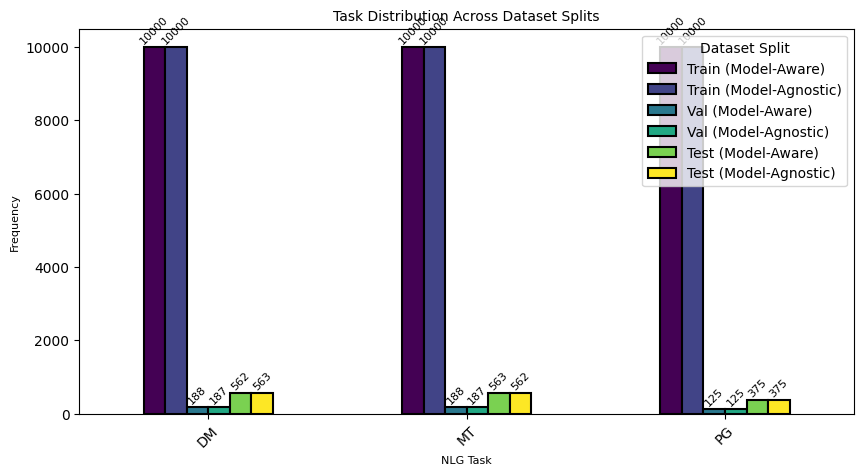

<Figure size 500x300 with 0 Axes>

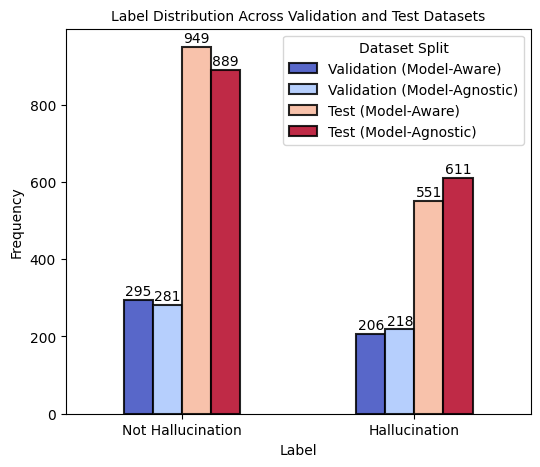

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
=
file_paths = {
    "Train (Model-Aware)": "/content/drive/MyDrive/SHROOM-Dataset/SHROOM_unlabeled-training-data-v2/train.model-aware.v2.json",
    "Train (Model-Agnostic)": "/content/drive/MyDrive/SHROOM-Dataset/SHROOM_unlabeled-training-data-v2/train.model-agnostic.json",
    "Val (Model-Aware)": "/content/drive/MyDrive/SHROOM-Dataset/val.model-aware.json",
    "Val (Model-Agnostic)": "/content/drive/MyDrive/SHROOM-Dataset/val.model-agnostic.json",
    "Test (Model-Aware)": "/content/drive/MyDrive/SHROOM-Dataset/SHROOM_test-labeled/test.model-aware.json",
    "Test (Model-Agnostic)": "/content/drive/MyDrive/SHROOM-Dataset/SHROOM_test-labeled/test.model-agnostic.json",
}

def load_json_data(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    return data

datasets = {name: load_json_data(path) for name, path in file_paths.items()}

task_distribution = {
    name: pd.Series([entry["task"] for entry in data]).value_counts()
    for name, data in datasets.items()
}

task_distribution_df = pd.DataFrame(task_distribution).fillna(0).astype(int)


label_distribution = {
    "Validation (Model-Aware)": pd.Series([entry["label"] for entry in datasets["Val (Model-Aware)"]]).value_counts(),
    "Validation (Model-Agnostic)": pd.Series([entry["label"] for entry in datasets["Val (Model-Agnostic)"]]).value_counts(),
    "Test (Model-Aware)": pd.Series([entry["label"] for entry in datasets["Test (Model-Aware)"]]).value_counts(),
    "Test (Model-Agnostic)": pd.Series([entry["label"] for entry in datasets["Test (Model-Agnostic)"]]).value_counts(),
}

label_distribution_df = pd.DataFrame(label_distribution).fillna(0).astype(int)

plt.figure(figsize=(12, 6))
ax = task_distribution_df.plot(kind="bar", colormap="viridis", figsize=(10, 5), edgecolor="black", linewidth=1.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=8, color='black', padding=1, rotation=45)

plt.title("Task Distribution Across Dataset Splits", fontsize=10)
plt.xlabel("NLG Task", fontsize=8)
plt.ylabel("Frequency", fontsize=8)
plt.legend(title="Dataset Split",  loc="upper right")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(5, 3))
ax = label_distribution_df.plot(kind="bar", colormap="coolwarm", alpha=0.85, figsize=(6, 5), edgecolor="black", linewidth=1.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, color='black', padding=1)

plt.title("Label Distribution Across Validation and Test Datasets", fontsize=10)
plt.xlabel("Label", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.legend(title="Dataset Split", loc="upper right")
plt.xticks(rotation=0)
plt.show()


<Figure size 1200x300 with 0 Axes>

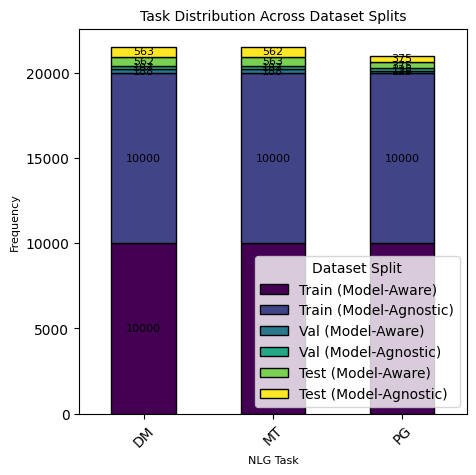

<Figure size 500x300 with 0 Axes>

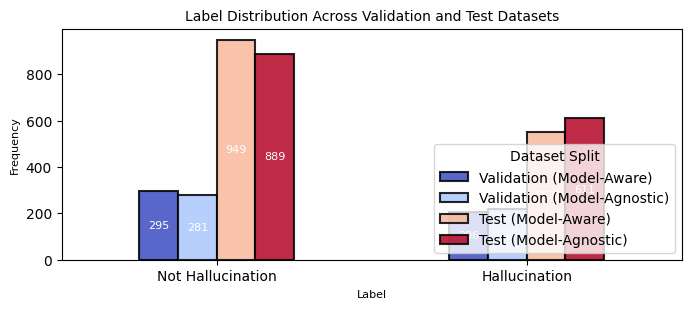

In [ ]:


import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = {name: load_json_data(path) for name, path in file_paths.items()}

task_distribution = {
    name: pd.Series([entry["task"] for entry in data]).value_counts()
    for name, data in datasets.items()
}
task_distribution_df = pd.DataFrame(task_distribution).fillna(0).astype(int)

label_distribution = {
    "Validation (Model-Aware)": pd.Series([entry["label"] for entry in datasets["Val (Model-Aware)"]]).value_counts(),
    "Validation (Model-Agnostic)": pd.Series([entry["label"] for entry in datasets["Val (Model-Agnostic)"]]).value_counts(),
    "Test (Model-Aware)": pd.Series([entry["label"] for entry in datasets["Test (Model-Aware)"]]).value_counts(),
    "Test (Model-Agnostic)": pd.Series([entry["label"] for entry in datasets["Test (Model-Agnostic)"]]).value_counts(),
}

label_distribution_df = pd.DataFrame(label_distribution).fillna(0).astype(int)

plt.figure(figsize=(12, 3))
ax = task_distribution_df.plot(kind="bar", stacked=True, colormap="viridis", figsize=(5, 5), edgecolor="black", linewidth=1)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=8, color='black')


plt.title("Task Distribution Across Dataset Splits", fontsize=10)
plt.xlabel("NLG Task", fontsize=8)
plt.ylabel("Frequency", fontsize=8)
plt.legend(title="Dataset Split",  loc="lower right")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(5, 3))
ax = label_distribution_df.plot(kind="bar", colormap="coolwarm", alpha=0.85, figsize=(8, 3), edgecolor="black", linewidth=1.5)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=8, color='white')

plt.title("Label Distribution Across Validation and Test Datasets", fontsize=10)
plt.xlabel("Label", fontsize=8)
plt.ylabel("Frequency", fontsize=8)
plt.legend(title="Dataset Split", loc="lower right")
plt.xticks(rotation=0)
plt.show()


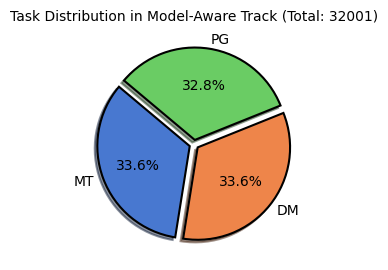

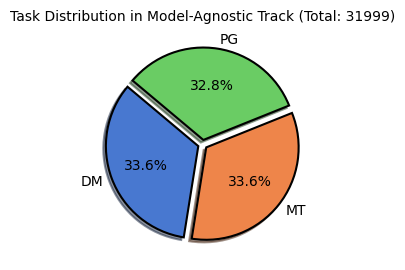

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load datasets
datasets = {name: load_json_data(path) for name, path in file_paths.items()}

# Aggregate task distribution for Model-Aware & Model-Agnostic tracks
task_distribution_aware = pd.Series(
    [entry["task"] for split in ["Train (Model-Aware)", "Val (Model-Aware)", "Test (Model-Aware)"]
     for entry in datasets[split]]
).value_counts()

task_distribution_agnostic = pd.Series(
    [entry["task"] for split in ["Train (Model-Agnostic)", "Val (Model-Agnostic)", "Test (Model-Agnostic)"]
     for entry in datasets[split]]
).value_counts()

# Define distinct colors for consistency
colors = sns.color_palette("muted")

# Function to plot a 2D pie chart with a 3D-like effect
def plot_pie_chart(task_distribution, title):
    fig, ax = plt.subplots(figsize=(3, 3))

    # Add depth illusion with shadow and explode
    explode = [0.05] * len(task_distribution)  # Slight separation for a 3D effect

    wedges, texts, autotexts = ax.pie(
        task_distribution, labels=task_distribution.index, autopct='%1.1f%%',
        colors=colors, startangle=140, wedgeprops={"edgecolor": "black", "linewidth": 1.5},
        explode=explode, shadow=True
    )

    # Style the text
    for text in texts + autotexts:
        text.set_fontsize(10)


    ax.set_title(f"{title} (Total: {task_distribution.sum()})", fontsize=10)
    plt.show()

# Plot pie chart for Model-Aware track
plot_pie_chart(task_distribution_aware, "Task Distribution in Model-Aware Track")

# Plot pie chart for Model-Agnostic track
plot_pie_chart(task_distribution_agnostic, "Task Distribution in Model-Agnostic Track")


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hyp               64000 non-null  object 
 1   tgt               64000 non-null  object 
 2   src               63999 non-null  object 
 3   ref               61000 non-null  object 
 4   task              64000 non-null  object 
 5   model             61000 non-null  object 
 6   Dataset           64000 non-null  object 
 7   labels            4000 non-null   object 
 8   label             4000 non-null   object 
 9   p(Hallucination)  4000 non-null   float64
 10  id                3000 non-null   float64
dtypes: float64(2), object(9)
memory usage: 5.4+ MB
None

Sample Data:
                                                 hyp  \
0  Of or pertaining to the language of a particul...   
1              Not coercive ; not involving coercion   
2  To express or expres

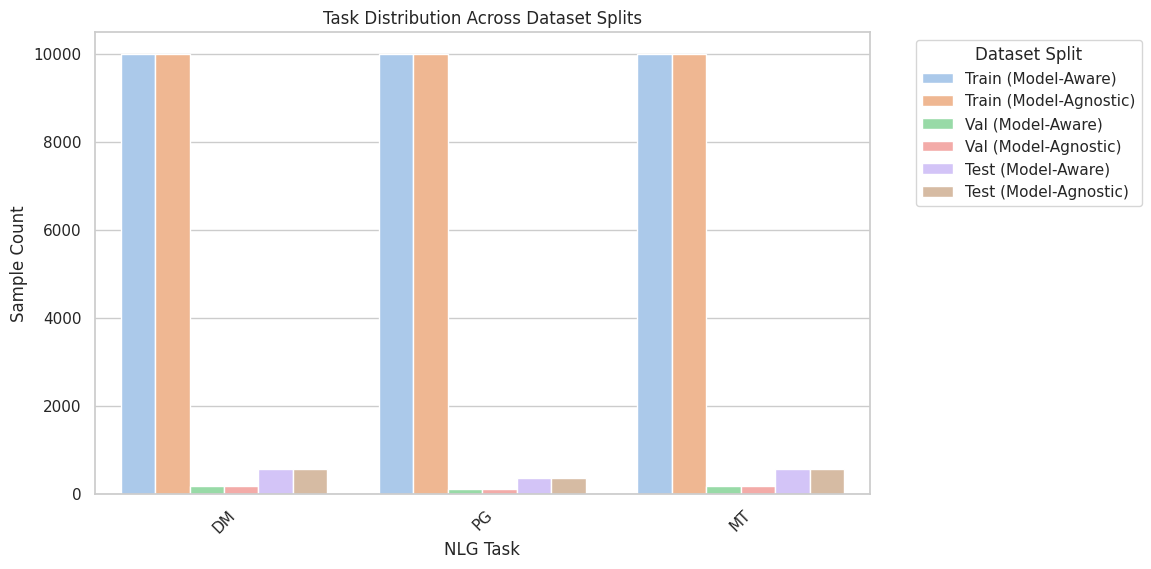


Label Distribution:
label
Not Hallucination    2414
Hallucination        1586
Name: count, dtype: int64


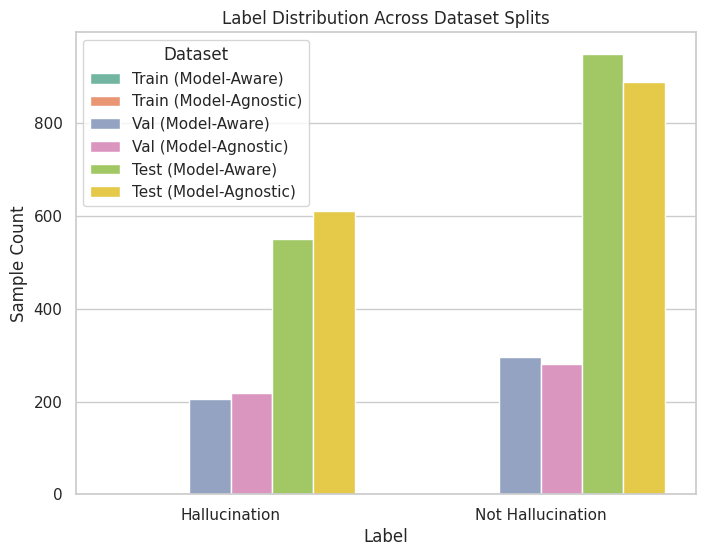

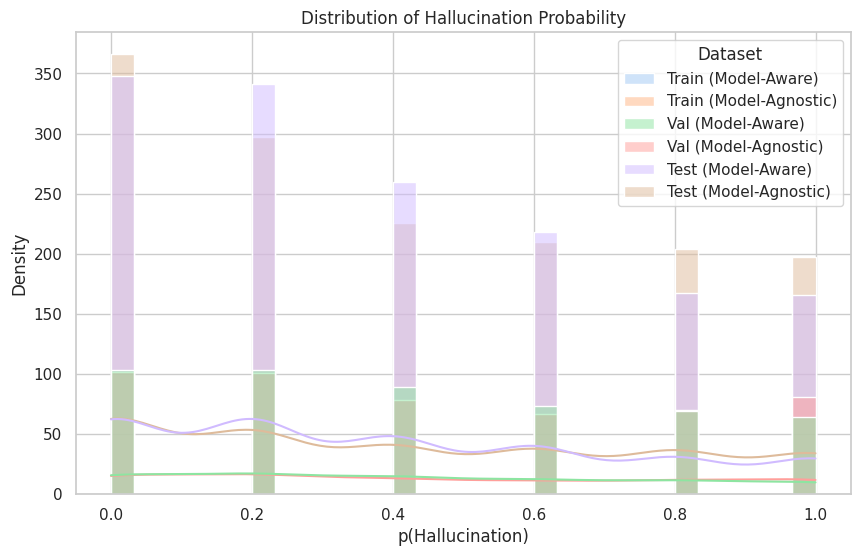


Model Distribution:
model
                                    30499
ltg/flan-t5-definition-en-base      10188
facebook/nllb-200-distilled-600M    10188
tuner007/pegasus_paraphrase         10125
Name: count, dtype: int64


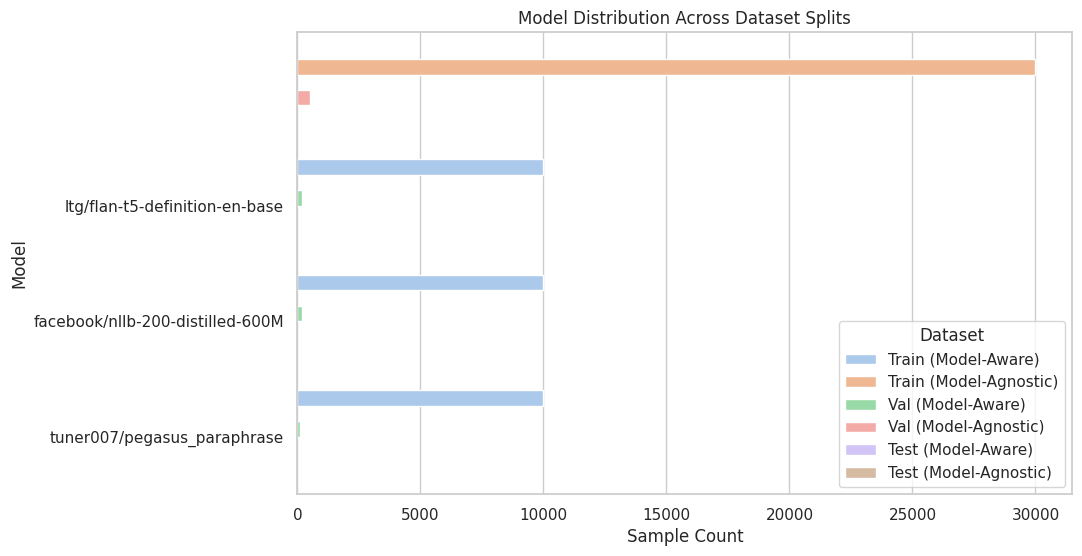

Preprocessed data saved to preprocessed_shroom_dataset.csv


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid", palette="pastel")

# File paths
file_paths = {
    "Train (Model-Aware)": "/content/drive/MyDrive/SHROOM-Dataset/SHROOM_unlabeled-training-data-v2/train.model-aware.v2.json",
    "Train (Model-Agnostic)": "/content/drive/MyDrive/SHROOM-Dataset/SHROOM_unlabeled-training-data-v2/train.model-agnostic.json",
    "Val (Model-Aware)": "/content/drive/MyDrive/SHROOM-Dataset/val.model-aware.json",
    "Val (Model-Agnostic)": "/content/drive/MyDrive/SHROOM-Dataset/val.model-agnostic.json",
    "Test (Model-Aware)": "/content/drive/MyDrive/SHROOM-Dataset/SHROOM_test-labeled/test.model-aware.json",
    "Test (Model-Agnostic)": "/content/drive/MyDrive/SHROOM-Dataset/SHROOM_test-labeled/test.model-agnostic.json",
}

# Function to load JSON data
def load_json_data(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    return data

# Load datasets
datasets = {name: load_json_data(path) for name, path in file_paths.items()}

# Convert datasets to DataFrames
def convert_to_df(name, data):
    df = pd.DataFrame(data)
    df['Dataset'] = name
    return df

dataframes = {name: convert_to_df(name, data) for name, data in datasets.items()}

# Combine all datasets into a single DataFrame for easier analysis
combined_df = pd.concat(dataframes.values(), ignore_index=True)

# Display dataset information
print("Dataset Overview:")
print(combined_df.info())
print("\nSample Data:")
print(combined_df.head())

# Check for missing values
print("\nMissing Values:")
print(combined_df.isnull().sum())

# Unique task types
print("\nUnique Task Types:")
print(combined_df['task'].unique())

# Distribution of task types
task_distribution = combined_df['task'].value_counts()
print("\nTask Distribution:")
print(task_distribution)

# Plot task distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=combined_df, x='task', hue='Dataset')
plt.title("Task Distribution Across Dataset Splits")
plt.xlabel("NLG Task")
plt.ylabel("Sample Count")
plt.legend(title="Dataset Split", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

# Distribution of hallucination labels
if 'label' in combined_df.columns:
    label_distribution = combined_df['label'].value_counts()
    print("\nLabel Distribution:")
    print(label_distribution)

    # Plot label distribution
    plt.figure(figsize=(8, 6))
    sns.countplot(data=combined_df, x='label', hue='Dataset', palette="Set2")
    plt.title("Label Distribution Across Dataset Splits")
    plt.xlabel("Label")
    plt.ylabel("Sample Count")
    plt.xticks(rotation=0)
    plt.show()

# Analyze p(Hallucination) field if available
if 'p(Hallucination)' in combined_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=combined_df, x='p(Hallucination)', hue='Dataset', kde=True, bins=30)
    plt.title("Distribution of Hallucination Probability")
    plt.xlabel("p(Hallucination)")
    plt.ylabel("Density")
    plt.show()

# Check if model-specific data is available
if 'model' in combined_df.columns:
    model_distribution = combined_df['model'].value_counts()
    print("\nModel Distribution:")
    print(model_distribution)

    # Plot model distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=combined_df, y='model', hue='Dataset', order=model_distribution.index)
    plt.title("Model Distribution Across Dataset Splits")
    plt.xlabel("Sample Count")
    plt.ylabel("Model")
    plt.show()

# Save preprocessed data to a new file
combined_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/preprocessed_shroom_dataset.csv", index=False)
print("Preprocessed data saved to preprocessed_shroom_dataset.csv")


In [ ]:
combined_df.head()

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id
0,Of or pertaining to the language of a particul...,"Of or pertaining to everyday language , as opp...","There are blacktips , silvertips , bronze whal...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN
1,Not coercive ; not involving coercion,Not coercive ; free of coercion,Mr. obama signed executive orders requiring al...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN
2,To express or express by words ; to express by...,To depict or portray .,Disloyal ? / the word is too good to paint out...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN
3,Having the power to authoritatively speak or w...,Having a commanding style .,"He instructed us in that booming , authoritati...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN
4,Without a scot .,"Without consequences or penalties , to go free...",To get off scot-free . What is the meaning of ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN


In [ ]:
print(combined_df.shape)
print(combined_df.Dataset.value_counts())

(64000, 11)
Dataset
Train (Model-Aware)       30000
Train (Model-Agnostic)    30000
Test (Model-Aware)         1500
Test (Model-Agnostic)      1500
Val (Model-Aware)           501
Val (Model-Agnostic)        499
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Columns with missing values to check
columns_with_nulls = ['hyp', 'tgt', 'src', 'ref', 'task', 'model', 'Dataset', 'labels', 'label', 'p(Hallucination)', 'id']

# Iterate through columns and print Dataset values where nulls are present
for column in columns_with_nulls:
    if combined_df[column].isnull().any():  # Check if column has nulls
        print(f"Dataset values where '{column}' is null:")
        print(combined_df.loc[combined_df[column].isnull(), 'Dataset'].unique())  # Print unique Dataset values for null rows
    else:
        print(f"No nulls found in column '{column}'")

No nulls found in column 'hyp'
No nulls found in column 'tgt'
Dataset values where 'src' is null:
['Train (Model-Aware)']
Dataset values where 'ref' is null:
['Test (Model-Aware)' 'Test (Model-Agnostic)']
No nulls found in column 'task'
Dataset values where 'model' is null:
['Test (Model-Aware)' 'Test (Model-Agnostic)']
No nulls found in column 'Dataset'
Dataset values where 'labels' is null:
['Train (Model-Aware)' 'Train (Model-Agnostic)']
Dataset values where 'label' is null:
['Train (Model-Aware)' 'Train (Model-Agnostic)']
Dataset values where 'p(Hallucination)' is null:
['Train (Model-Aware)' 'Train (Model-Agnostic)']
Dataset values where 'id' is null:
['Train (Model-Aware)' 'Train (Model-Agnostic)' 'Val (Model-Aware)'
 'Val (Model-Agnostic)']


In [ ]:
# Model values null in test set
combined_df[combined_df['model'].isnull()]['Dataset'].value_counts()

,count
Dataset,
Test (Model-Aware),1500
Test (Model-Agnostic),1500


In [ ]:
# Snapshot of test set
combined_df[combined_df['Dataset']=='Test (Model-Aware)']

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id
61000,A crazy person .,Crazy person ; crackpot or lunatic .,"Sadly , at the end of his life , Luther became...",NaN,DM,NaN,Test (Model-Aware),"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.0,0.0
61001,Historians have strongly criticized the FBI's ...,Historians have criticized past FBI policies f...,इतिहासकार लोगन FBI के पिछला नीति के बहुत आलोचन...,NaN,MT,NaN,Test (Model-Aware),"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.0,4.0
61002,The eastern islands of the Indian Ocean are lo...,The East African Islands are in the Indian Oce...,Àwọn erekùsù ìlà oòrùn adúláwọ̀ wà ní òkun Ind...,NaN,MT,NaN,Test (Model-Aware),"[Not Hallucination, Hallucination, Hallucinati...",Hallucination,0.6,5.0
61003,"The social group of a person , especially a wo...",High society .,Smith was first introduced into society at the...,NaN,DM,NaN,Test (Model-Aware),"[Hallucination, Hallucination, Hallucination, ...",Hallucination,1.0,9.0
61004,It uses a giant rocket over 100 feet high to l...,It takes a giant rocket over a 100 feet high t...,Ngini mamakai roket raksasa malabihi 100 kaki ...,NaN,MT,NaN,Test (Model-Aware),"[Hallucination, Not Hallucination, Not Halluci...",Not Hallucination,0.4,11.0
...,...,...,...,...,...,...,...,...,...,...,...
62495,"If you want small, tasty pastries, try calling...","If you want some small though rich pastries, t...",നിങ്ങൾക്ക് ചെറുതും രുചികരവുമായ പേസ്ട്രികൾ വേണമ...,NaN,MT,NaN,Test (Model-Aware),"[Hallucination, Hallucination, Not Hallucinati...",Hallucination,0.6,2988.0
62496,It is a bad country.,,It is one of the most badly governed countries...,NaN,PG,NaN,Test (Model-Aware),"[Hallucination, Hallucination, Hallucination, ...",Hallucination,0.8,2991.0
62497,There isn't currently a case of this.,,This is not currently the case.,NaN,PG,NaN,Test (Model-Aware),"[Hallucination, Hallucination, Not Hallucinati...",Not Hallucination,0.4,2995.0
62498,Characteristic of a game ; playful .,Full of sport ; playful,Tom Stoppard secured his place on the theatric...,NaN,DM,NaN,Test (Model-Aware),"[Hallucination, Hallucination, Hallucination, ...",Hallucination,1.0,2997.0


##### Class balance

In [ ]:
# Analyze label distribution
label_distribution = combined_df['label'].value_counts()
label_distribution_percentage = (label_distribution / label_distribution.sum()) * 100

# Display results
print("Label Distribution:")
print(label_distribution)
print("\nLabel Distribution Percentage:")
print(label_distribution_percentage)


Label Distribution:
label
Not Hallucination    2414
Hallucination        1586
Name: count, dtype: int64

Label Distribution Percentage:
label
Not Hallucination    60.35
Hallucination        39.65
Name: count, dtype: float64


#### Preprocessing

###### Text Cleaning and Normalization - Not done as context is important and with MT other languages also present.
###### Feature Engineering
###### Handle Imbalanced Label Distribution - Not done as imbalance is not severe (60-40 split), undersampling not done
###### Handling Annotator Disagreement - Not done as not much disagreement, can implement annotator consensus (e.g., Consensus_Score = 1 - Disagreement_Score) to help the model prioritize highly agreed-upon examples later.
###### Removing Duplicate or Redundant Samples - Done

##### Duplicates removal

In [ ]:
## Test set having duplicates
combined_df[combined_df['hyp']=="It'll only take you a minute."]

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id
62675,It'll only take you a minute.,It'll only take a minute of your time.,У тебя это займет всего минуту.,NaN,MT,NaN,Test (Model-Agnostic),"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.0,322.0
63770,It'll only take you a minute.,It'll only take a minute of your time.,У тебя это займет всего минуту.,NaN,MT,NaN,Test (Model-Agnostic),"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.0,2542.0


In [ ]:
## Overall duplicates
combined_df[combined_df.duplicated(subset=['src', 'tgt', 'hyp', 'ref','model','task','p(Hallucination)','Dataset'], keep=False)]

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id
30001,Tom is never where he should be.,Tom is never where he's supposed to be.,"Тома никогда нет там, где он должен быть.",either,MT,,Train (Model-Agnostic),NaN,NaN,NaN,NaN
30002,It's hard for me to work with Tom.,I have trouble working with Tom.,Мне сложно работать с Томом.,either,MT,,Train (Model-Agnostic),NaN,NaN,NaN,NaN
30003,"Water, please.",I'd like some water.,"Воду, пожалуйста.",either,MT,,Train (Model-Agnostic),NaN,NaN,NaN,NaN
30004,I didn't expect Tom to betray me.,I didn't think that Tom would betray me.,"Я не ожидал, что Том предаст меня.",either,MT,,Train (Model-Agnostic),NaN,NaN,NaN,NaN
30007,Why can't you accept me as I am?,Why can't you accept me as I am?,"Почему вы не можете принять меня таким, какой ...",either,MT,,Train (Model-Agnostic),NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
63284,I thought you'd want to drink.,I thought you'd be thirsty.,"Я думал, вы захотите пить.",NaN,MT,NaN,Test (Model-Agnostic),"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.0,1541.0
63387,You know who killed her?,Do you know who killed her?,"Ты знаешь, кто её убил?",NaN,MT,NaN,Test (Model-Agnostic),"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.0,1726.0
63631,Did he bring a towel?,Did you bring a towel?,Полотенце принёс?,NaN,MT,NaN,Test (Model-Agnostic),"[Hallucination, Hallucination, Hallucination, ...",Hallucination,1.0,2243.0
63770,It'll only take you a minute.,It'll only take a minute of your time.,У тебя это займет всего минуту.,NaN,MT,NaN,Test (Model-Agnostic),"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.0,2542.0


In [ ]:
import json
import pandas as pd

# Check for duplicate samples based on the combination of 'src', 'tgt', and 'hyp'
duplicates = combined_df[combined_df.duplicated(subset=['src', 'tgt', 'hyp', 'ref','model','task','p(Hallucination)','Dataset'], keep=False)]

print("Duplicate Samples:")
print(duplicates)

# Remove duplicates and create a cleaned DataFrame
cleaned_df = combined_df.drop_duplicates(subset=['src', 'tgt', 'hyp', 'ref','model','task','p(Hallucination)','Dataset'])

print("\nTotal Samples Before Removing Duplicates:", len(combined_df))
print("Total Samples After Removing Duplicates:", len(cleaned_df))

# Save the cleaned data to a new file
cleaned_df.to_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv", index=False)
print("\nCleaned data saved to 'cleaned_shroom_dataset.csv'")


Duplicate Samples:
                                      hyp  \
30001    Tom is never where he should be.   
30002  It's hard for me to work with Tom.   
30003                      Water, please.   
30004   I didn't expect Tom to betray me.   
30007    Why can't you accept me as I am?   
...                                   ...   
63284      I thought you'd want to drink.   
63387            You know who killed her?   
63631               Did he bring a towel?   
63770       It'll only take you a minute.   
63914               You know what he did?   

                                            tgt  \
30001   Tom is never where he's supposed to be.   
30002          I have trouble working with Tom.   
30003                      I'd like some water.   
30004  I didn't think that Tom would betray me.   
30007          Why can't you accept me as I am?   
...                                         ...   
63284               I thought you'd be thirsty.   
63387               Do you know 

###### Class Balance after Preprocessing

In [ ]:
# Analyze label distribution
print("Shape: ", cleaned_df.shape)
print(cleaned_df.Dataset.value_counts())
label_distribution = cleaned_df['label'].value_counts()
label_distribution_percentage = (label_distribution / label_distribution.sum()) * 100

# Display results
print("Label Distribution:")
print(label_distribution)
print("\nLabel Distribution Percentage:")
print(label_distribution_percentage)

'''
(64000, 11)
Dataset
Train (Model-Aware)       30000
Train (Model-Agnostic)    30000
Test (Model-Aware)         1500
Test (Model-Agnostic)      1500
Val (Model-Aware)           501
Val (Model-Agnostic)        499
'''

Shape:  (62644, 11)
Dataset
Train (Model-Aware)       30000
Train (Model-Agnostic)    28649
Test (Model-Aware)         1500
Test (Model-Agnostic)      1495
Val (Model-Aware)           501
Val (Model-Agnostic)        499
Name: count, dtype: int64
Label Distribution:
label
Not Hallucination    2410
Hallucination        1585
Name: count, dtype: int64

Label Distribution Percentage:
label
Not Hallucination    60.325407
Hallucination        39.674593
Name: count, dtype: float64


###### EDA on Cleaned Dataset

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
Index: 62644 entries, 0 to 63999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hyp               62644 non-null  object 
 1   tgt               62644 non-null  object 
 2   src               62643 non-null  object 
 3   ref               59649 non-null  object 
 4   task              62644 non-null  object 
 5   model             59649 non-null  object 
 6   Dataset           62644 non-null  object 
 7   labels            3995 non-null   object 
 8   label             3995 non-null   object 
 9   p(Hallucination)  3995 non-null   float64
 10  id                2995 non-null   float64
dtypes: float64(2), object(9)
memory usage: 5.7+ MB
None

Sample Data:
                                                 hyp  \
0  Of or pertaining to the language of a particul...   
1              Not coercive ; not involving coercion   
2  To express or express by 

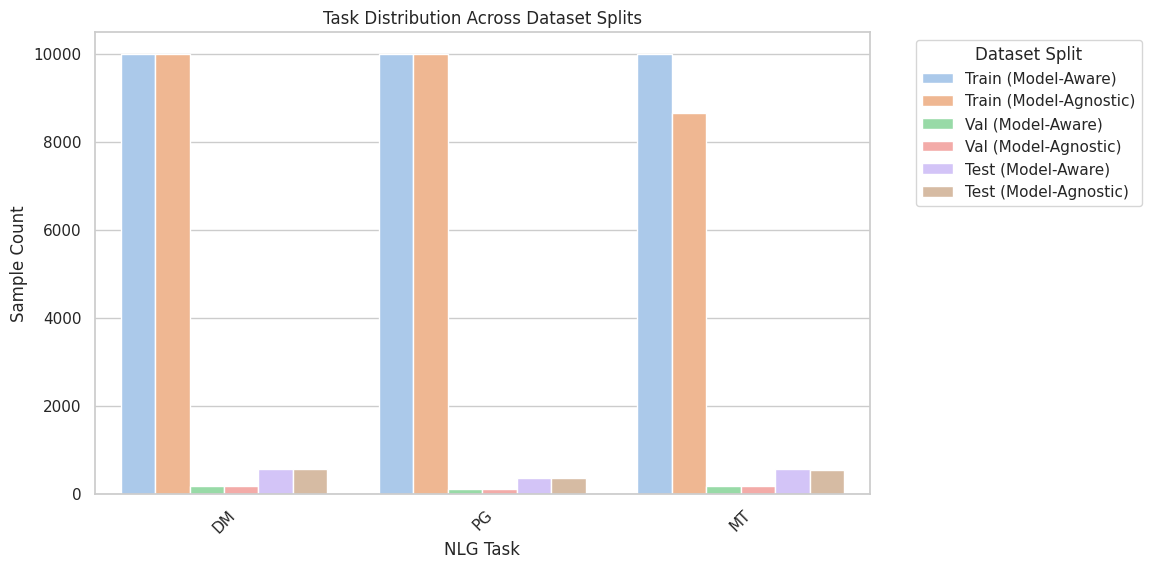


Label Distribution:
label
Not Hallucination    2410
Hallucination        1585
Name: count, dtype: int64


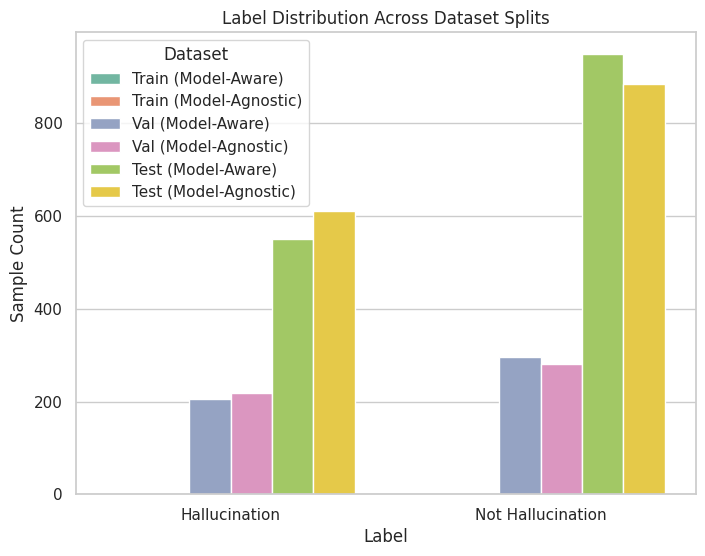

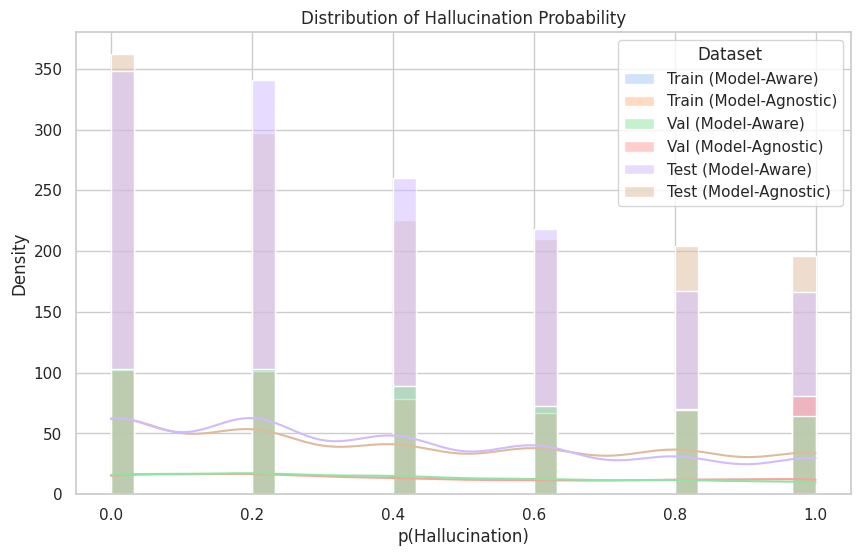


Model Distribution:
model
                                    29148
ltg/flan-t5-definition-en-base      10188
facebook/nllb-200-distilled-600M    10188
tuner007/pegasus_paraphrase         10125
Name: count, dtype: int64


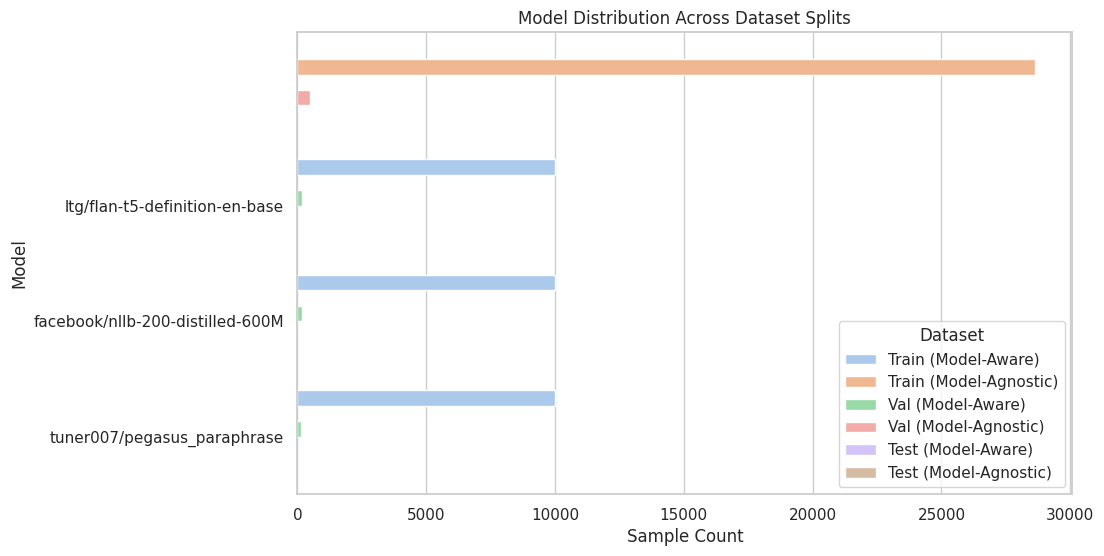

In [ ]:
# Display dataset information
print("Dataset Overview:")
print(cleaned_df.info())
print("\nSample Data:")
print(cleaned_df.head())

# Check for missing values
print("\nMissing Values:")
print(cleaned_df.isnull().sum())

# Unique task types
print("\nUnique Task Types:")
print(cleaned_df['task'].unique())

# Distribution of task types
task_distribution = cleaned_df['task'].value_counts()
print("\nTask Distribution:")
print(task_distribution)

# Plot task distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=cleaned_df, x='task', hue='Dataset')
plt.title("Task Distribution Across Dataset Splits")
plt.xlabel("NLG Task")
plt.ylabel("Sample Count")
plt.legend(title="Dataset Split", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

# Distribution of hallucination labels
if 'label' in cleaned_df.columns:
    label_distribution = cleaned_df['label'].value_counts()
    print("\nLabel Distribution:")
    print(label_distribution)

    # Plot label distribution
    plt.figure(figsize=(8, 6))
    sns.countplot(data=cleaned_df, x='label', hue='Dataset', palette="Set2")
    plt.title("Label Distribution Across Dataset Splits")
    plt.xlabel("Label")
    plt.ylabel("Sample Count")
    plt.xticks(rotation=0)
    plt.show()

# Analyze p(Hallucination) field if available
if 'p(Hallucination)' in cleaned_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=cleaned_df, x='p(Hallucination)', hue='Dataset', kde=True, bins=30)
    plt.title("Distribution of Hallucination Probability")
    plt.xlabel("p(Hallucination)")
    plt.ylabel("Density")
    plt.show()

# Check if model-specific data is available
if 'model' in cleaned_df.columns:
    model_distribution = cleaned_df['model'].value_counts()
    print("\nModel Distribution:")
    print(model_distribution)

    # Plot model distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=cleaned_df, y='model', hue='Dataset', order=model_distribution.index)
    plt.title("Model Distribution Across Dataset Splits")
    plt.xlabel("Sample Count")
    plt.ylabel("Model")
    plt.show()

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62644 entries, 0 to 62643
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hyp               62644 non-null  object 
 1   tgt               42144 non-null  object 
 2   src               62643 non-null  object 
 3   ref               59649 non-null  object 
 4   task              62644 non-null  object 
 5   model             30501 non-null  object 
 6   Dataset           62644 non-null  object 
 7   labels            3995 non-null   object 
 8   label             3995 non-null   object 
 9   p(Hallucination)  3995 non-null   float64
 10  id                2995 non-null   float64
dtypes: float64(2), object(9)
memory usage: 5.3+ MB
None

Sample Data:
                                                 hyp  \
0  Of or pertaining to the language of a particul...   
1              Not coercive ; not involving coercion   
2  To express or expres

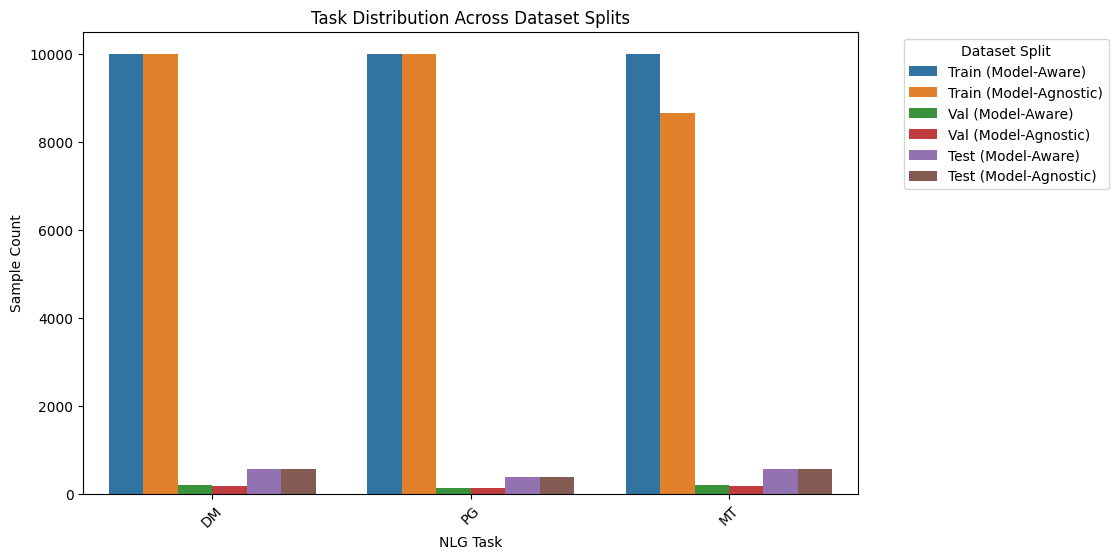


Label Distribution:
label
Not Hallucination    2410
Hallucination        1585
Name: count, dtype: int64


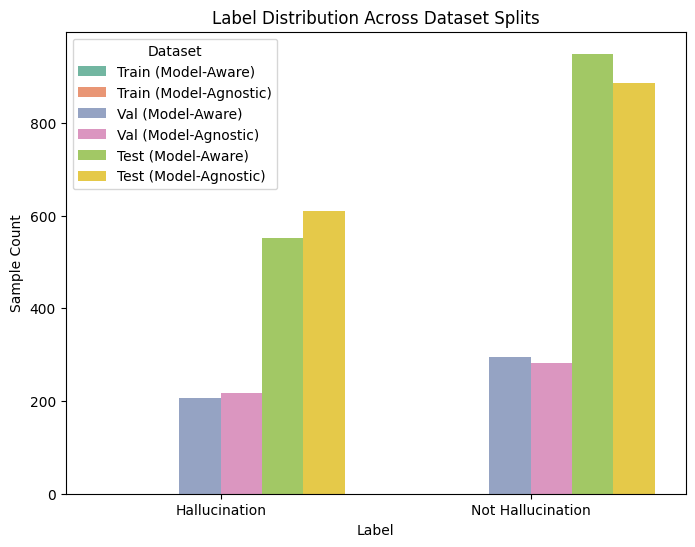

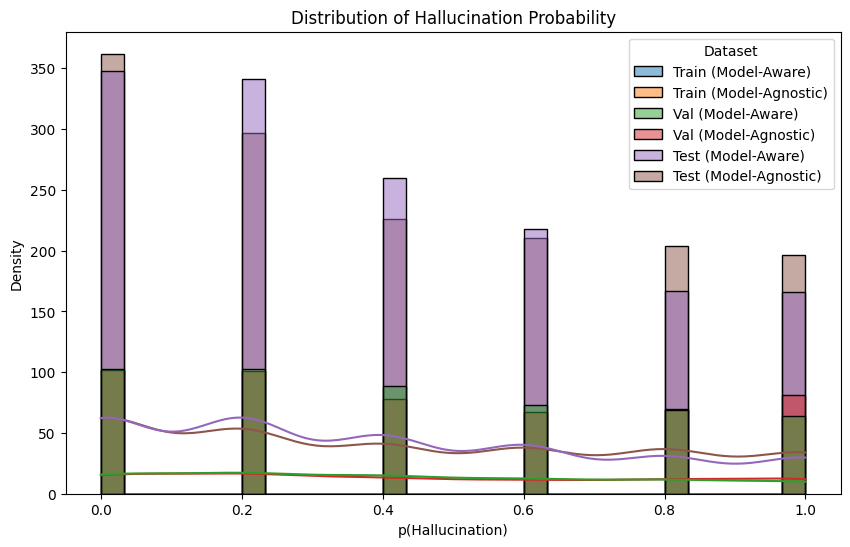


Model Distribution:
model
ltg/flan-t5-definition-en-base      10188
facebook/nllb-200-distilled-600M    10188
tuner007/pegasus_paraphrase         10125
Name: count, dtype: int64


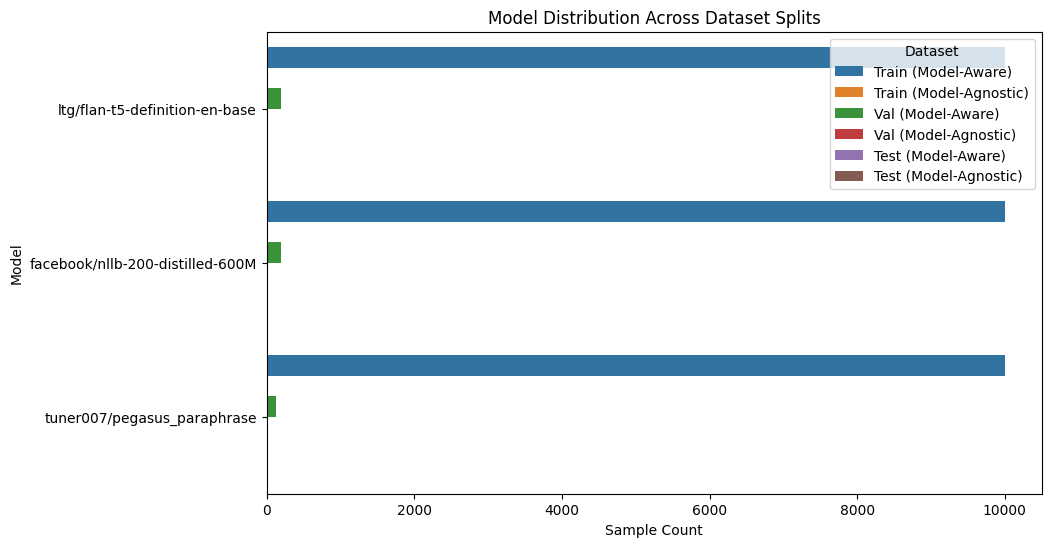

In [ ]:
# Display dataset information
print("Dataset Overview:")
print(cleaned_df.info())
print("\nSample Data:")
print(cleaned_df.head())

# Check for missing values
print("\nMissing Values:")
print(cleaned_df.isnull().sum())

# Unique task types
print("\nUnique Task Types:")
print(cleaned_df['task'].unique())

# Distribution of task types
task_distribution = cleaned_df['task'].value_counts()
print("\nTask Distribution:")
print(task_distribution)

# Plot task distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=cleaned_df, x='task', hue='Dataset')
plt.title("Task Distribution Across Dataset Splits")
plt.xlabel("NLG Task")
plt.ylabel("Sample Count")
plt.legend(title="Dataset Split", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

# Distribution of hallucination labels
if 'label' in cleaned_df.columns:
    label_distribution = cleaned_df['label'].value_counts()
    print("\nLabel Distribution:")
    print(label_distribution)

    # Plot label distribution
    plt.figure(figsize=(8, 6))
    sns.countplot(data=cleaned_df, x='label', hue='Dataset', palette="Set2")
    plt.title("Label Distribution Across Dataset Splits")
    plt.xlabel("Label")
    plt.ylabel("Sample Count")
    plt.xticks(rotation=0)
    plt.show()

# Analyze p(Hallucination) field if available
if 'p(Hallucination)' in cleaned_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=cleaned_df, x='p(Hallucination)', hue='Dataset', kde=True, bins=30)
    plt.title("Distribution of Hallucination Probability")
    plt.xlabel("p(Hallucination)")
    plt.ylabel("Density")
    plt.show()

# Check if model-specific data is available
if 'model' in cleaned_df.columns:
    model_distribution = cleaned_df['model'].value_counts()
    print("\nModel Distribution:")
    print(model_distribution)

    # Plot model distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=cleaned_df, y='model', hue='Dataset', order=model_distribution.index)
    plt.title("Model Distribution Across Dataset Splits")
    plt.xlabel("Sample Count")
    plt.ylabel("Model")
    plt.show()

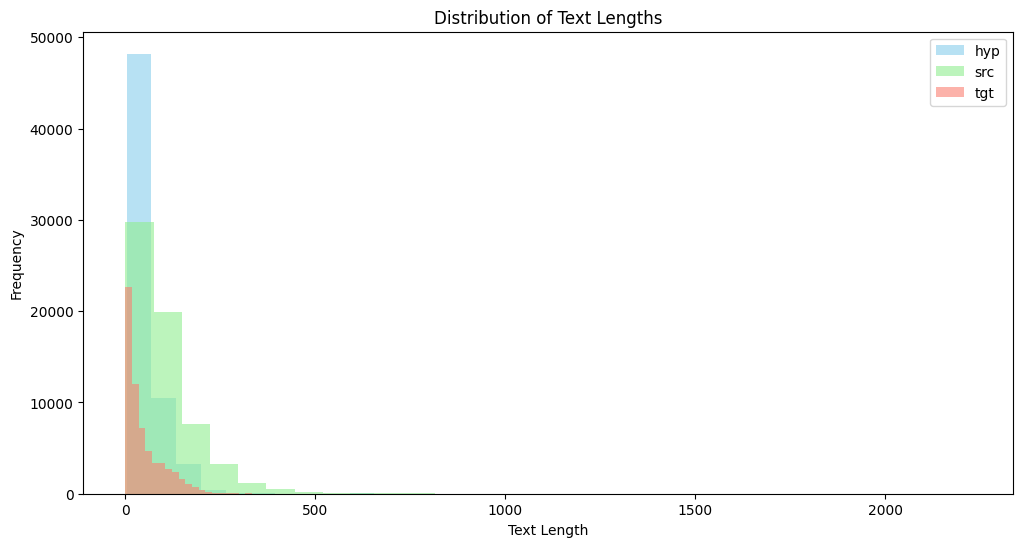

Summary Table of Text Lengths:
  Feature  Max Length  Min Length  Average Length
0     hyp        1961           3       53.257295
1     src        2226           0       98.641817
2     tgt         526           0       46.355373


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_text_lengths(df):
    """
    Analyzes the maximum, minimum, and average length of main text features: 'hyp', 'src', 'tgt'.
    """
    # Calculate lengths for each feature
    df['hyp_length'] = df['hyp'].fillna('').apply(len)
    df['src_length'] = df['src'].fillna('').apply(len)
    df['tgt_length'] = df['tgt'].fillna('').apply(len)

    # Calculate statistics
    length_stats = pd.DataFrame({
        'Feature': ['hyp', 'src', 'tgt'],
        'Max Length': [df['hyp_length'].max(), df['src_length'].max(), df['tgt_length'].max()],
        'Min Length': [df['hyp_length'].min(), df['src_length'].min(), df['tgt_length'].min()],
        'Average Length': [df['hyp_length'].mean(), df['src_length'].mean(), df['tgt_length'].mean()]
    })

    # Plotting the distribution of text lengths
    plt.figure(figsize=(12, 6))
    plt.hist(df['hyp_length'], bins=30, alpha=0.6, label='hyp', color='skyblue')
    plt.hist(df['src_length'], bins=30, alpha=0.6, label='src', color='lightgreen')
    plt.hist(df['tgt_length'], bins=30, alpha=0.6, label='tgt', color='salmon')
    plt.title("Distribution of Text Lengths")
    plt.xlabel("Text Length")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    return length_stats

# Usage
length_stats = analyze_text_lengths(cleaned_df)

print("Summary Table of Text Lengths:")
print(length_stats)

###### EDA on Test Set - 2995 alone

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

# Display dataset information
print("Dataset Overview:")
print(test_df.info())
print("\nSample Data:")
print(test_df.head())

# Check for missing values
print("\nMissing Values:")
print(test_df.isnull().sum())

# Unique task types
print("\nUnique Task Types:")
print(test_df['task'].unique())

# Distribution of task types
task_distribution = test_df['task'].value_counts()
print("\nTask Distribution:")
print(task_distribution)


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
Index: 2995 entries, 59649 to 62643
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hyp               2995 non-null   object 
 1   tgt               2620 non-null   object 
 2   src               2995 non-null   object 
 3   ref               0 non-null      object 
 4   task              2995 non-null   object 
 5   model             0 non-null      object 
 6   Dataset           2995 non-null   object 
 7   labels            2995 non-null   object 
 8   label             2995 non-null   object 
 9   p(Hallucination)  2995 non-null   float64
 10  id                2995 non-null   float64
dtypes: float64(2), object(9)
memory usage: 280.8+ KB
None

Sample Data:
                                                     hyp  \
59649                                   A crazy person .   
59650  Historians have strongly criticized the FBI's ...   
59651  The 

In [ ]:
test_df[test_df['task']=='MT'][:-200]

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id
59650,Historians have strongly criticized the FBI's ...,Historians have criticized past FBI policies f...,इतिहासकार लोगन FBI के पिछला नीति के बहुत आलोचन...,NaN,MT,NaN,Test (Model-Aware),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.0,4.0
59651,The eastern islands of the Indian Ocean are lo...,The East African Islands are in the Indian Oce...,Àwọn erekùsù ìlà oòrùn adúláwọ̀ wà ní òkun Ind...,NaN,MT,NaN,Test (Model-Aware),"['Not Hallucination', 'Hallucination', 'Halluc...",Hallucination,0.6,5.0
59653,It uses a giant rocket over 100 feet high to l...,It takes a giant rocket over a 100 feet high t...,Ngini mamakai roket raksasa malabihi 100 kaki ...,NaN,MT,NaN,Test (Model-Aware),"['Hallucination', 'Not Hallucination', 'Not Ha...",Not Hallucination,0.4,11.0
59656,"Since humans arrived in Galapagos, a large num...","Since the arrival of man to the Galapagos, man...",من وقت ما وصل الإنسان إلى غالاباغوس، تم تقديم ...,NaN,MT,NaN,Test (Model-Aware),"['Hallucination', 'Hallucination', 'Not Halluc...",Not Hallucination,0.4,17.0
59657,Travelers are strongly advised to be on the lo...,Travellers are strongly advised to be aware of...,Omwe ali paulendo akulangizidwa ndithu kukhala...,NaN,MT,NaN,Test (Model-Aware),"['Not Hallucination', 'Not Hallucination', 'Ha...",Not Hallucination,0.4,20.0
...,...,...,...,...,...,...,...,...,...,...,...
62079,Tom might be coming today.,Tom will probably come today.,"Том, может быть, сегодня придёт.",NaN,MT,NaN,Test (Model-Agnostic),"['Not Hallucination', 'Not Hallucination', 'Ha...",Not Hallucination,0.2,1807.0
62080,"Tom's a very unpleasant person, right?","Tom is really obnoxious, isn't he?","Том очень неприятный человек, да?",NaN,MT,NaN,Test (Model-Agnostic),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.0,1808.0
62086,"I'd like to help you, but I can't stay here an...","I wish I could help you, but I can't stay any ...","Я хотел бы помочь вам, но я не могу больше зде...",NaN,MT,NaN,Test (Model-Agnostic),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.0,1824.0
62088,This song was shot in Tom's head for three days.,That song has been stuck in Tom's head for thr...,Эта песня три дня крутилась у Тома в голове.,NaN,MT,NaN,Test (Model-Agnostic),"['Not Hallucination', 'Hallucination', 'Halluc...",Hallucination,0.6,1828.0


In [ ]:
test_df[(test_df['task']=='PG') & (test_df['label'] == 'Not Hallucination')]

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id
59655,Certain types of fruit and vegetables are stil...,NaN,"We are still short of tobacco, wood, non-proce...",NaN,PG,NaN,Test (Model-Aware),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.2,13.0
59658,Nationalism was powerful and existed.,NaN,"Nationalism did exist, and it was a powerful f...",NaN,PG,NaN,Test (Model-Aware),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.0,25.0
59660,The issue of employment doesn't have to do wit...,NaN,"To conclude, the issue of employment does not ...",NaN,PG,NaN,Test (Model-Aware),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.0,31.0
59667,There hasn't been a trial or investigation in ...,NaN,"The tragedy continues, 20 years on, because th...",NaN,PG,NaN,Test (Model-Aware),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.2,48.0
59674,A colleague said this.,NaN,This was actually said by one of our colleagues.,NaN,PG,NaN,Test (Model-Aware),"['Not Hallucination', 'Hallucination', 'Not Ha...",Not Hallucination,0.2,60.0
...,...,...,...,...,...,...,...,...,...,...,...
62630,Are you going to fire me?,"What, am I being fired?",Are you gonna fire me?,NaN,PG,NaN,Test (Model-Agnostic),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.0,2975.0
62631,Wh-What's the rush?,Why are you in a hurry?,What's the rush?,NaN,PG,NaN,Test (Model-Agnostic),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.4,2977.0
62635,"But luckily, I've got a plan.","Oh, luckily, I have a plan.","Fortunately, I got a plan.",NaN,PG,NaN,Test (Model-Agnostic),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.0,2985.0
62642,Can anyone corroborate that?,Can anyone confirm that?,Can anyone back you up on that?,NaN,PG,NaN,Test (Model-Agnostic),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.0,2996.0


##### Handling Annotator Disagreement

In [ ]:
import numpy as np
import pandas as pd

def analyze_disagreement(cleaned_df):

    filtered_df = cleaned_df[cleaned_df['labels'].notna()]

     def convert_labels(label_list):
        return [1 if label == 'Hallucination' else 0 for label in label_list]

    filtered_df['labels'] = filtered_df['labels'].apply(convert_labels)

     filtered_df['Disagreement_Score'] = filtered_df['labels'].apply(lambda x: np.var(x))

    summary_stats = filtered_df.groupby('Dataset')['Disagreement_Score'].agg(['mean', 'std', 'min', 'max'])

    return filtered_df[['Dataset', 'Disagreement_Score']], summary_stats

disagreement_df, disagreement_summary = analyze_disagreement(cleaned_df)

# Display results
print("Annotator Disagreement Scores:")
print(disagreement_df.head())

print("\nSummary Statistics for Annotator Disagreement:")
print(disagreement_summary)


Annotator Disagreement Scores:
                 Dataset  Disagreement_Score
60000  Val (Model-Aware)                0.24
60001  Val (Model-Aware)                0.00
60002  Val (Model-Aware)                0.24
60003  Val (Model-Aware)                0.24
60004  Val (Model-Aware)                0.24

Summary Statistics for Annotator Disagreement:
                           mean       std  min   max
Dataset                                             
Test (Model-Agnostic)  0.123612  0.100520  0.0  0.24
Test (Model-Aware)     0.130667  0.099789  0.0  0.24
Val (Model-Agnostic)   0.124569  0.100064  0.0  0.24
Val (Model-Aware)      0.132535  0.099339  0.0  0.24


<ipython-input-43-3c1ff764fdb7>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['labels'] = filtered_df['labels'].apply(convert_labels)
<ipython-input-43-3c1ff764fdb7>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Disagreement_Score'] = filtered_df['labels'].apply(lambda x: np.var(x))


##### Feature Engineering
Purpose: Create additional features to help the model understand hallucination patterns.
Steps:
Compute semantic similarity scores between input, target, and hypothesis using Sentence-BERT or Cosine Similarity.
Generate length-based features, such as the length ratio between hypothesis and reference text.

In [ ]:
import pandas as pd
cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
cleaned_df.shape

(62644, 11)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def optimized_feature_engineering(df):
    """
    Perform optimized feature engineering: semantic similarity (reduced), length ratios.
    """
    # Handle missing values by filling with empty strings
    df['src'] = df['src'].fillna('')
    df['hyp'] = df['hyp'].fillna('')

    # Limit vocabulary size in TF-IDF Vectorizer to reduce RAM usage
    vectorizer = TfidfVectorizer(max_features=5000)  # Limit to 5000 most important words
    tfidf_matrix = vectorizer.fit_transform(df['src'] + " " + df['hyp'])

    # Compute cosine similarity in mini-batches to prevent memory overload
    batch_size = 1000  # Reduce this further if necessary
    similarity_scores = []
    for i in range(0, tfidf_matrix.shape[0], batch_size):
        end = min(i + batch_size, tfidf_matrix.shape[0])
        batch_similarity = cosine_similarity(tfidf_matrix[i:end], tfidf_matrix[i:end]).diagonal()
        similarity_scores.extend(batch_similarity)

    df['Semantic_Similarity'] = similarity_scores

    # Optimized length ratio calculation using NumPy
    df['Hyp_Length'] = np.array([len(text) for text in df['hyp']])
    df['Src_Length'] = np.array([len(text) for text in df['src']])
    df['Length_Ratio'] = df['Hyp_Length'] / (df['Src_Length'] + 1e-6)  # Avoid division by zero

    print("Optimized Feature Engineering Done!")
    return df


# Usage
feature_df = optimized_feature_engineering(cleaned_df)
feature_df.to_csv("optimized_feature_dataset.csv", index=False)

Optimized Feature Engineering Done!


In [ ]:
feature_df.head(-10)

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,Semantic_Similarity,Hyp_Length,Src_Length,Length_Ratio
0,Of or pertaining to the language of a particul...,"Of or pertaining to everyday language , as opp...","There are blacktips , silvertips , bronze whal...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,1.0,74,298,0.248322
1,Not coercive ; not involving coercion,Not coercive ; free of coercion,Mr. obama signed executive orders requiring al...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,1.0,37,160,0.231250
2,To express or express by words ; to express by...,To depict or portray .,Disloyal ? / the word is too good to paint out...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,1.0,54,94,0.574468
3,Having the power to authoritatively speak or w...,Having a commanding style .,"He instructed us in that booming , authoritati...",tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,1.0,68,102,0.666667
4,Without a scot .,"Without consequences or penalties , to go free...",To get off scot-free . What is the meaning of ...,tgt,DM,ltg/flan-t5-definition-en-base,Train (Model-Aware),NaN,NaN,NaN,NaN,1.0,16,57,0.280702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62629,Let's go closer to the business.,Let's get to the point.,Давайте ближе к делу.,NaN,MT,NaN,Test (Model-Agnostic),"['Hallucination', 'Not Hallucination', 'Halluc...",Not Hallucination,0.4,2970.0,1.0,32,21,1.523809
62630,Are you going to fire me?,"What, am I being fired?",Are you gonna fire me?,NaN,PG,NaN,Test (Model-Agnostic),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.0,2975.0,1.0,25,22,1.136364
62631,Wh-What's the rush?,Why are you in a hurry?,What's the rush?,NaN,PG,NaN,Test (Model-Agnostic),"['Not Hallucination', 'Not Hallucination', 'No...",Not Hallucination,0.4,2977.0,1.0,19,16,1.187500
62632,Full of sneers.,Expressing contempt.,"Not that you do actually sneer , of course — t...",NaN,DM,NaN,Test (Model-Agnostic),"['Not Hallucination', 'Hallucination', 'Halluc...",Hallucination,0.6,2978.0,1.0,15,163,0.092025


In [ ]:
feature_df['Semantic_Similarity'].value_counts()

,count
Semantic_Similarity,
1.0,34217
1.0,24238
1.0,2577
1.0,581
1.0,449
0.0,340
1.0,147
1.0,57
1.0,32
